# Task 4 · Channel effectiveness, measured

**Ali Afzal** · BSAI-7B-102 · Data Visualization · Week 2

Cleveland & McGill ranked visual channels by how accurately people judge a ratio with each one. This
notebook repeats their test at a very small scale: one reader and 30 charts.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DATA = Path("data")
CHARTS = Path("charts")
CHARTS.mkdir(exist_ok=True)

# Paul Tol "bright" palette: stays distinct for colour-blind readers
RED, BLUE, GREY, INK = "#ee6677", "#4477aa", "#bbbbbb", "#333333"

plt.rcParams.update({
    "figure.dpi": 100,
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlelocation": "left",
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
})


def save(fig, name):
    fig.savefig(CHARTS / name, dpi=300, bbox_inches="tight")

from matplotlib.patches import Rectangle

In [2]:
trials = pd.read_csv(DATA / "channel_trials.csv")
trials.pivot_table(index="channel", columns="true_ratio", values="trial", aggfunc="count")

true_ratio,0.15,0.25,0.40,0.55,0.70,0.85
channel,,,,,,
angle,1,1,1,1,1,1
area,1,1,1,1,1,1
colour,1,1,1,1,1,1
length,1,1,1,1,1,1
position,1,1,1,1,1,1


## 1. One pair, five channels

Each panel shows the same pair of values through one channel only. There are no labels, ticks or numbers,
so the reader has nothing to go on except the channel itself.

In [3]:
SCALE = 100


def bare(ax):
    ax.set_xticks([])
    ax.set_yticks([])
    for side in ax.spines.values():
        side.set_visible(False)


def by_position(ax, big, small):
    ax.scatter([0, 1], [big, small], s=70, color=INK, zorder=3)
    ax.set_xlim(-0.7, 1.7)
    ax.set_ylim(0, SCALE)
    bare(ax)
    ax.spines[["left", "bottom"]].set_visible(True)   # the shared scale, no ticks


def by_length(ax, big, small):
    ax.bar([0, 1], [big, small], width=0.5, color=INK)
    ax.set_xlim(-0.7, 1.7)
    ax.set_ylim(0, SCALE)
    bare(ax)
    ax.spines["bottom"].set_visible(True)   # common zero baseline


def by_angle(ax, big, small):
    ax.pie([big, small], colors=[INK, GREY], startangle=90, counterclock=False,
           wedgeprops={"edgecolor": "white", "linewidth": 2})


def by_area(ax, big, small):
    # s is AREA in points^2, so s proportional to value is an honest area encoding
    ax.scatter([0, 1], [0, 0], s=[big * 30, small * 30], color=INK)
    ax.set_xlim(-0.8, 1.8)
    ax.set_ylim(-1, 1)
    bare(ax)


def by_colour(ax, big, small):
    # sequential lightness ramp: darker = more. A rainbow has no order to judge.
    for x, v in [(0, big), (1, small)]:
        ax.add_patch(Rectangle((x - 0.35, -0.35), 0.7, 0.7, facecolor=plt.cm.Greys(v / SCALE),
                               edgecolor="#999999", lw=0.8))
    ax.set_xlim(-0.7, 1.7)
    ax.set_ylim(-1, 1)
    ax.set_aspect("equal")
    bare(ax)


ENCODE = {"position": by_position, "length": by_length, "angle": by_angle,
          "area": by_area, "colour": by_colour}

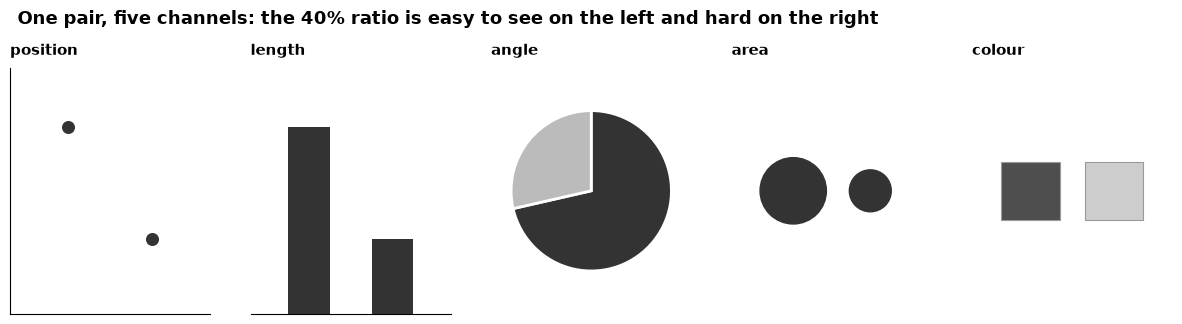

In [4]:
big, small = 76, 30.4   # trial 3: small is 40% of big

fig, axes = plt.subplots(1, 5, figsize=(15, 3.2))
for ax, (name, draw) in zip(axes, ENCODE.items()):
    draw(ax, big, small)
    cell = ax.get_subplotspec().get_position(fig)   # same box for every panel, whatever its aspect
    fig.text(cell.x0, cell.y1 + 0.04, name, fontweight="bold", fontsize=11)
fig.suptitle("One pair, five channels: the 40% ratio is easy to see on the left and hard on the right",
             x=0.13, y=1.06, ha="left", fontsize=13, fontweight="bold")
save(fig, "t4_five_channels.png")

**What the eye does with each one**

- **Position and length.** Both are measured from the same baseline, so the eye compares two distances
  directly, and 40% looks like 40%.
- **Angle.** Two wedges with no shared baseline. People also read pie slices partly by area and arc length,
  which blurs the judgement.
- **Area.** The circle's *area* is proportional to the value, not its radius. That's the honest encoding, and
  it avoids the classic area lie. It still reads wrong, because the eye underestimates differences in area.
  The small circle looks closer to half the big one than to 40%.
- **Colour.** Lightness has no zero. The eye can say "lighter" but not "40% as dark". The ramp runs light to
  dark in one direction only. A rainbow would have no order to judge at all.

## 2–3. The experiment

The reader saw all 30 charts in shuffled order and was asked the same question each time: **"The smaller one
is what percentage of the larger?"** They didn't see any true answers until the end.

Error for each trial = |estimate − true ratio|, in percentage points. 0 is perfect, and 20 means off by 20
points.

In [5]:
from IPython.display import clear_output, display

RESULTS = Path("channel_results.csv")
# To run: set READER, flip RUN_EXPERIMENT to True and run this cell with the reader.
# Then flip it back to False and Restart & Run All.
RUN_EXPERIMENT = False
READER = "a classmate"


def ask_percent(prompt):
    while True:
        try:
            value = float(input(prompt).strip().rstrip("%"))
        except ValueError:
            value = -1
        if 0 <= value <= 100:
            return value
        print("A number from 0 to 100, please.")


def run_channels(trials, reader):
    done = trials.copy()
    done["shown_as"] = 0
    for shown, i in enumerate(np.random.default_rng().permutation(len(done)), 1):
        t = done.iloc[i]
        clear_output(wait=True)
        print(f"Chart {shown} of {len(done)}")
        fig, ax = plt.subplots(figsize=(4, 3))
        ENCODE[t.channel](ax, t.value_large, t.value_small)
        display(fig)
        plt.close(fig)
        done.loc[done.index[i], "reader_estimate"] = ask_percent("The smaller one is what % of the larger? ")
        done.loc[done.index[i], "shown_as"] = shown
    clear_output()
    done["reader"] = reader
    return done


if RUN_EXPERIMENT:
    run_channels(trials, READER).to_csv(RESULTS, index=False)

if RESULTS.exists():
    results = pd.read_csv(RESULTS)
    results["absolute_error"] = (results.reader_estimate / 100 - results.true_ratio).abs()
    results.to_csv(RESULTS, index=False)
    display(results)
else:
    results = None
    print("No channel_results.csv yet. Set RUN_EXPERIMENT = True and run this cell with your reader.")

No channel_results.csv yet. Set RUN_EXPERIMENT = True and run this cell with your reader.


## 4. Rank the channels

In [6]:
THEORY = ["position", "length", "angle", "area", "colour"]   # Cleveland & McGill; no volume in this file

if results is None:
    print("Waiting for channel_results.csv.")
else:
    err = results.groupby("channel").absolute_error.mean().sort_values() * 100
    best, worst = err.index[0], err.index[-1]

    fig, ax = plt.subplots(figsize=(8, 4.5))
    y = np.arange(len(err))
    ax.barh(y, err.values, color=[RED if c == best else GREY for c in err.index], height=0.6)
    for i, channel in enumerate(err.index):
        trial_err = results.loc[results.channel == channel, "absolute_error"] * 100
        ax.scatter(trial_err, np.full(len(trial_err), i), s=14, color=INK, zorder=3, linewidths=0)
        ax.text(err[channel] + 0.4, i - 0.36, f"{err[channel]:.1f}", fontsize=8.5,
                color=RED if channel == best else INK)
    ax.set_yticks(y, err.index)
    ax.invert_yaxis()
    ax.tick_params(axis="y", length=0)
    ax.set_xlim(0, None)
    ax.set_xlabel("Absolute error (percentage points). Bar = mean, dots = the 6 trials")
    ax.set_title(f"{best.capitalize()} was read most accurately: off by {err[best]:.1f} points "
                 f"on average vs {err[worst]:.1f} for {worst}")
    ax.annotate(f"One reader ({READER}), 30 trials, 6 per channel. Shorter bar = more accurate.",
                xy=(0, -0.2), xycoords="axes fraction", fontsize=8, color="#777777")
    save(fig, "t4_channel_ranking.png")

    rank = pd.DataFrame({"mean_error_pts": err.round(1),
                         "my_rank": range(1, len(err) + 1),
                         "theory_rank": [THEORY.index(c) + 1 for c in err.index]})
    rank["agrees"] = rank.my_rank == rank.theory_rank
    rho = np.corrcoef(rank.my_rank, rank.theory_rank)[0, 1]
    print(f"Rank agreement with Cleveland & McGill (Spearman rho): {rho:.2f}")
    display(rank)

Waiting for channel_results.csv.


**Reading the chart.** A shorter bar means a more accurate channel. The dots are the six individual trials,
and their spread matters as much as the mean. With only six trials, one wild guess can drag a bar a long
way.

> **My reader's ranking** *(fill in from the table)*: who it was, where it agrees with
> `position > length > angle > area > colour` and where it doesn't. For each swap, give the most likely
> reason, such as a lucky guess on a pie or a ratio that happened to be easy to judge.

## 5. Apply it: `petal_length` on a strong channel and a weak one

Both charts have the same message: **setosa petals are far shorter than the others.**

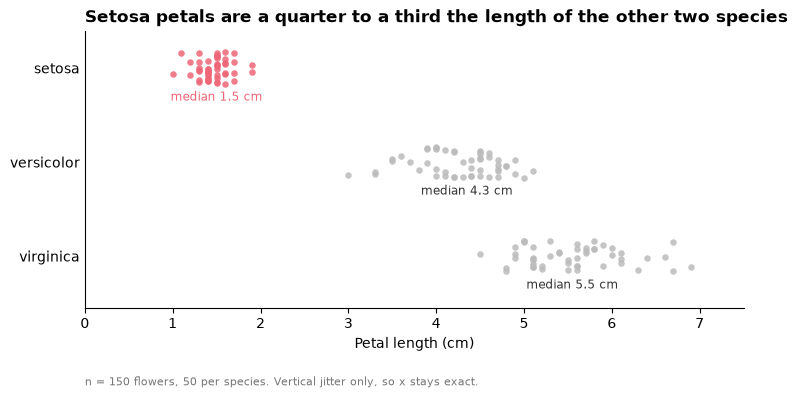

In [7]:
iris = pd.read_csv(DATA / "iris.csv")
SPECIES = ["setosa", "versicolor", "virginica"]
med = iris.groupby("species").petal_length.median()
rng = np.random.default_rng(0)

fig, ax = plt.subplots(figsize=(8.5, 3.6))
for i, sp in enumerate(SPECIES):
    d = iris[iris.species == sp]
    hot = sp == "setosa"
    ax.scatter(d.petal_length, i + rng.uniform(-0.17, 0.17, len(d)), s=22, alpha=0.85,
               color=RED if hot else GREY, linewidths=0)
    ax.text(med[sp], i + 0.24, f"median {med[sp]:.1f} cm", ha="center", va="top", fontsize=8.5,
            color=RED if hot else INK)
ax.set_yticks(range(3), SPECIES)
ax.set_ylim(2.55, -0.4)
ax.tick_params(axis="y", length=0)
ax.set_xlim(0, 7.5)
ax.set_xlabel("Petal length (cm)")
ax.set_title("Setosa petals are a quarter to a third the length of the other two species")
ax.annotate("n = 150 flowers, 50 per species. Vertical jitter only, so x stays exact.",
            xy=(0, -0.28), xycoords="axes fraction", fontsize=8, color="#777777")
save(fig, "t4_iris_position.png")

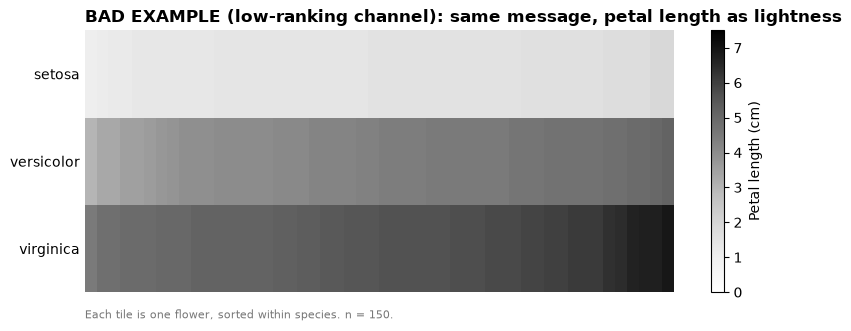

In [8]:
tiles = np.vstack([np.sort(iris.loc[iris.species == sp, "petal_length"].to_numpy()) for sp in SPECIES])

fig, ax = plt.subplots(figsize=(9.5, 3.4))
im = ax.imshow(tiles, cmap="Greys", vmin=0, vmax=7.5, aspect="auto")
ax.set_yticks(range(3), SPECIES)
ax.set_xticks([])
ax.tick_params(axis="y", length=0)
for side in ax.spines.values():
    side.set_visible(False)
fig.colorbar(im, ax=ax, label="Petal length (cm)")
ax.set_title("BAD EXAMPLE (low-ranking channel): same message, petal length as lightness")
ax.annotate("Each tile is one flower, sorted within species. n = 150.",
            xy=(0, -0.1), xycoords="axes fraction", fontsize=8, color="#777777")
save(fig, "t4_iris_colour_bad.png")

**I'd publish the position chart.** The reason is how accurately each one can be decoded:

- **Position:** each flower sits on one shared, labelled scale. The reader can see that setosa is around 1.5
  cm and the others around 4–6 cm. They can also judge the ratio directly, because both distances are measured
  from the same zero.
- **Lightness:** the reader can tell setosa is *lighter*, but can't tell by how much. Lightness has no
  natural zero. Neighbouring tiles change how a tile looks (simultaneous contrast). And turning a grey into a
  number means a trip to the colorbar and back, which uses working memory. A ratio judgement on lightness is
  a guess.

The colour version gets the *direction* right ("setosa is smaller") and loses the *size* of the difference,
which is the actual message.

## The question: what 30 data points can and can't support

**It can** show what one reader did: their errors, their ranking and whether it looked like Cleveland &
McGill's. It's a good way to *feel* the difference between judging a bar and judging a shade of grey.

**It can't** support any general claim. There's one reader and six trials per channel, with no repeats and
no confidence intervals. A single careless answer moves a channel's mean by several points. Swapping the
order of two neighbouring channels, like angle vs area, is well within the noise. There's also no
statistical power to tell those apart.

**Why follow the published ranking anyway:** it comes from many readers and hundreds of judgements, and later
studies have replicated it, for example Heer & Bostock's 2010 crowdsourced repeat. One noisy sample that
disagrees isn't evidence against it. It's what a small sample looks like. You design for the average
reader, and the ranking describes the average reader.